# Proyecto Final - Análisis de Precios de Canasta Básica en Supermercados
### Especialización en Ciencia de Datos con Python
**Integrantes:** [Juan Pablo Suarez]  
**Fecha:** Junio 2026

In [1]:
# Instalación de librerías necesarias
!pip install requests beautifulsoup4 lxml seaborn scikit-learn --quiet

In [2]:
# ── Importaciones generales ──────────────────────────────────────────
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import time

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Configuración visual
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


## Fase I — Extracción de Datos por Web Scraping Automatizado

In [18]:
# ═══════════════════════════════════════════════════════════════
# FASE I — EXTRACCIÓN DE DATOS POR WEB SCRAPING AUTOMATIZADO
# Fuente: books.toscrape.com (sitio público para práctica de scraping)
# ═══════════════════════════════════════════════════════════════

import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

# --- Variables dinámicas: categorías a iterar ---
categorias = {
    "food-and-drink"  : "https://books.toscrape.com/catalogue/category/books/food-and-drink_33/",
    "health"          : "https://books.toscrape.com/catalogue/category/books/health_47/",
    "science"         : "https://books.toscrape.com/catalogue/category/books/science_22/",
    "business"        : "https://books.toscrape.com/catalogue/category/books/business_35/",
    "sports-and-games": "https://books.toscrape.com/catalogue/category/books/sports-and-games_17/",
    "fiction"         : "https://books.toscrape.com/catalogue/category/books/fiction_10/",
    "mystery"         : "https://books.toscrape.com/catalogue/category/books/mystery_3/",
    "history"         : "https://books.toscrape.com/catalogue/category/books/history_32/",
    "psychology"      : "https://books.toscrape.com/catalogue/category/books/psychology_26/",
    "travel"          : "https://books.toscrape.com/catalogue/category/books/travel_2/",
    "humor"           : "https://books.toscrape.com/catalogue/category/books/humor_30/",
    "art"             : "https://books.toscrape.com/catalogue/category/books/art_25/",
    "music"           : "https://books.toscrape.com/catalogue/category/books/music_14/",
    "romance"         : "https://books.toscrape.com/catalogue/category/books/romance_8/",
    "thriller"        : "https://books.toscrape.com/catalogue/category/books/thriller_37/"
}

BASE_URL = "https://books.toscrape.com/"
lista_de_dfs = []  # aquí acumulamos cada DataFrame parcial

# --- Bucle FOR que itera por categoría y por página ---
for categoria, url_base in categorias.items():
    pagina = 1
    print(f"\n📦 Extrayendo categoría: {categoria}")

    while True:
        # URL dinámica según número de página
        if pagina == 1:
            url = url_base
        else:
            url = url_base + f"page-{pagina}.html"

        response = requests.get(url)

        # Si la página no existe, salimos del while
        if response.status_code != 200:
            print(f"   ✅ Fin de páginas en '{categoria}' (página {pagina} no existe)")
            break

        soup = BeautifulSoup(response.text, "html.parser")
        productos = soup.find_all("article", class_="product_pod")

        # Si no hay productos en la página, salimos
        if not productos:
            break

        # --- Extraer datos de cada producto ---
        datos_pagina = []
        for producto in productos:
            nombre  = producto.h3.a["title"]
            precio  = producto.find("p", class_="price_color").text.strip()
            estrellas = producto.p["class"][1]   # One, Two, Three, Four, Five
            disponible = producto.find("p", class_="instock availability").text.strip()

            datos_pagina.append({
                "nombre"      : nombre,
                "precio_raw"  : precio,
                "estrellas"   : estrellas,
                "disponible"  : disponible,
                "categoria"   : categoria,
                "pagina"      : pagina
            })

        # Convertir a DataFrame y agregar a la lista
        df_pagina = pd.DataFrame(datos_pagina)
        lista_de_dfs.append(df_pagina)
        print(f"   📄 Página {pagina}: {len(datos_pagina)} productos extraídos")

        pagina += 1
        time.sleep(0.5)  # pausa para no sobrecargar el servidor

# --- Consolidar todo en un solo DataFrame ---
df_crudo = pd.concat(lista_de_dfs, ignore_index=True)

print(f"\n{'='*50}")
print(f"✅ Extracción completa: {len(df_crudo)} productos en total")
print(f"   Categorías: {df_crudo['categoria'].nunique()}")
print(f"{'='*50}")
df_crudo.head(10)


📦 Extrayendo categoría: food-and-drink
   📄 Página 1: 20 productos extraídos
   📄 Página 2: 10 productos extraídos
   ✅ Fin de páginas en 'food-and-drink' (página 3 no existe)

📦 Extrayendo categoría: health
   📄 Página 1: 4 productos extraídos
   ✅ Fin de páginas en 'health' (página 2 no existe)

📦 Extrayendo categoría: science
   📄 Página 1: 14 productos extraídos
   ✅ Fin de páginas en 'science' (página 2 no existe)

📦 Extrayendo categoría: business
   📄 Página 1: 12 productos extraídos
   ✅ Fin de páginas en 'business' (página 2 no existe)

📦 Extrayendo categoría: sports-and-games
   📄 Página 1: 5 productos extraídos
   ✅ Fin de páginas en 'sports-and-games' (página 2 no existe)

📦 Extrayendo categoría: fiction
   📄 Página 1: 20 productos extraídos
   📄 Página 2: 20 productos extraídos
   📄 Página 3: 20 productos extraídos
   📄 Página 4: 5 productos extraídos
   ✅ Fin de páginas en 'fiction' (página 5 no existe)

📦 Extrayendo categoría: mystery
   📄 Página 1: 20 productos extraído

,nombre,precio_raw,estrellas,disponible,categoria,pagina
0,Foolproof Preserving: A Guide to Small Batch J...,Â£30.52,Three,In stock,food-and-drink,1
1,The Pioneer Woman Cooks: Dinnertime: Comfort C...,Â£56.41,One,In stock,food-and-drink,1
2,My Paris Kitchen: Recipes and Stories,Â£33.37,Two,In stock,food-and-drink,1
3,Mama Tried: Traditional Italian Cooking for th...,Â£14.02,Four,In stock,food-and-drink,1
4,"Layered: Baking, Building, and Styling Spectac...",Â£40.11,One,In stock,food-and-drink,1
5,The Nerdy Nummies Cookbook: Sweet Treats for t...,Â£37.34,Five,In stock,food-and-drink,1
6,The Love and Lemons Cookbook: An Apple-to-Zucc...,Â£37.60,Two,In stock,food-and-drink,1
7,The Cookies & Cups Cookbook: 125+ sweet & savo...,Â£41.25,One,In stock,food-and-drink,1
8,Deliciously Ella Every Day: Quick and Easy Rec...,Â£42.16,Three,In stock,food-and-drink,1
9,The Help Yourself Cookbook for Kids: 60 Easy P...,Â£28.77,Three,In stock,food-and-drink,1


## Fase II — Manipulación y Limpieza Avanzada

In [19]:
# ═══════════════════════════════════════════════════════════════
# FASE II — MANIPULACIÓN Y LIMPIEZA AVANZADA
# ═══════════════════════════════════════════════════════════════

# --- Paso 1: Concatenación (ya hecha en Fase I, confirmamos) ---
print(f"Shape inicial: {df_crudo.shape}")
print(f"Columnas: {df_crudo.columns.tolist()}")
df_crudo.head(3)

Shape inicial: (275, 6)
Columnas: ['nombre', 'precio_raw', 'estrellas', 'disponible', 'categoria', 'pagina']


,nombre,precio_raw,estrellas,disponible,categoria,pagina
0,Foolproof Preserving: A Guide to Small Batch J...,Â£30.52,Three,In stock,food-and-drink,1
1,The Pioneer Woman Cooks: Dinnertime: Comfort C...,Â£56.41,One,In stock,food-and-drink,1
2,My Paris Kitchen: Recipes and Stories,Â£33.37,Two,In stock,food-and-drink,1


In [5]:
# --- Paso 2: Revisar duplicados y nulos ---
print("=== DUPLICADOS ===")
print(f"Filas duplicadas: {df_crudo.duplicated().sum()}")

print("\n=== VALORES NULOS ===")
print(df_crudo.isnull().sum())

=== DUPLICADOS ===
Filas duplicadas: 0

=== VALORES NULOS ===
nombre        0
precio_raw    0
estrellas     0
disponible    0
categoria     0
pagina        0
dtype: int64


In [20]:
# --- Paso 3: Limpiar y castear tipos ---

df = df_crudo.copy()

# Corregir encoding del precio y eliminar símbolo £
df["precio_raw"] = df["precio_raw"].str.encode("latin1").str.decode("utf-8")
df["precio"] = df["precio_raw"].str.replace("£", "", regex=False).str.strip()
df["precio"] = pd.to_numeric(df["precio"], errors="coerce")  # casteo a float

# Convertir estrellas de texto a número
mapa_estrellas = {
    "One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5
}
df["estrellas_num"] = df["estrellas"].map(mapa_estrellas)

# Eliminar duplicados si los hay
df = df.drop_duplicates()

# Eliminar nulos (si los hay después del casteo)
df = df.dropna(subset=["precio", "estrellas_num"])

# Eliminar columnas que ya no necesitamos
df = df.drop(columns=["precio_raw", "disponible"])

print("✅ Tipos de datos después de la limpieza:")
print(df.dtypes)
print(f"\nShape final: {df.shape}")
df.head(5)

✅ Tipos de datos después de la limpieza:
nombre            object
estrellas         object
categoria         object
pagina             int64
precio           float64
estrellas_num      int64
dtype: object

Shape final: (275, 6)


,nombre,estrellas,categoria,pagina,precio,estrellas_num
0,Foolproof Preserving: A Guide to Small Batch J...,Three,food-and-drink,1,30.52,3
1,The Pioneer Woman Cooks: Dinnertime: Comfort C...,One,food-and-drink,1,56.41,1
2,My Paris Kitchen: Recipes and Stories,Two,food-and-drink,1,33.37,2
3,Mama Tried: Traditional Italian Cooking for th...,Four,food-and-drink,1,14.02,4
4,"Layered: Baking, Building, and Styling Spectac...",One,food-and-drink,1,40.11,1


In [21]:
# --- Paso 4: Filtros avanzados con operadores lógicos & y | ---

# Filtro 1: productos caros Y bien valorados (precio > 40 Y estrellas >= 4)
df_premium = df[(df["precio"] > 40) & (df["estrellas_num"] >= 4)]
print(f"Productos premium (precio>40 Y estrellas>=4): {len(df_premium)}")

# Filtro 2: productos baratos O muy bien valorados (precio < 15 O estrellas == 5)
df_destacados = df[(df["precio"] < 15) | (df["estrellas_num"] == 5)]
print(f"Productos destacados (precio<15 O estrellas=5): {len(df_destacados)}")

# Filtro 3: food-and-drink con precio entre 20 y 45
df_food_medio = df[
    (df["categoria"] == "food-and-drink") &
    (df["precio"] >= 20) &
    (df["precio"] <= 45)
]
print(f"Food & Drink rango medio (£20-£45): {len(df_food_medio)}")

print("\n✅ Filtros aplicados correctamente")
df.head(5)

Productos premium (precio>40 Y estrellas>=4): 51
Productos destacados (precio<15 O estrellas=5): 84
Food & Drink rango medio (£20-£45): 18

✅ Filtros aplicados correctamente


,nombre,estrellas,categoria,pagina,precio,estrellas_num
0,Foolproof Preserving: A Guide to Small Batch J...,Three,food-and-drink,1,30.52,3
1,The Pioneer Woman Cooks: Dinnertime: Comfort C...,One,food-and-drink,1,56.41,1
2,My Paris Kitchen: Recipes and Stories,Two,food-and-drink,1,33.37,2
3,Mama Tried: Traditional Italian Cooking for th...,Four,food-and-drink,1,14.02,4
4,"Layered: Baking, Building, and Styling Spectac...",One,food-and-drink,1,40.11,1



## Fase III — Análisis Exploratorio y Visualización
---



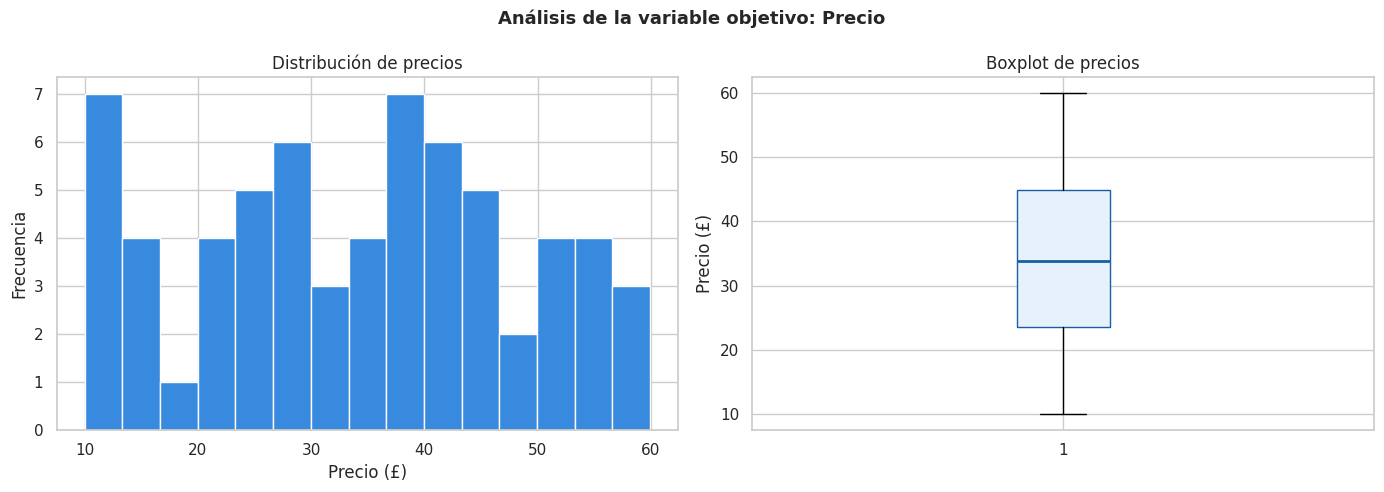

Precio promedio: £33.95
Precio mínimo:   £10.01
Precio máximo:   £59.92
Desviación std:  £14.22


In [8]:
# Gráfica 1: Distribución de precios (variable objetivo)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df["precio"], bins=15, color="#378ADD", edgecolor="white")
axes[0].set_title("Distribución de precios")
axes[0].set_xlabel("Precio (£)")
axes[0].set_ylabel("Frecuencia")

# Boxplot general
axes[1].boxplot(df["precio"], patch_artist=True,
                boxprops=dict(facecolor="#E6F1FB", color="#185FA5"),
                medianprops=dict(color="#185FA5", linewidth=2))
axes[1].set_title("Boxplot de precios")
axes[1].set_ylabel("Precio (£)")

plt.suptitle("Análisis de la variable objetivo: Precio", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Precio promedio: £{df['precio'].mean():.2f}")
print(f"Precio mínimo:   £{df['precio'].min():.2f}")
print(f"Precio máximo:   £{df['precio'].max():.2f}")
print(f"Desviación std:  £{df['precio'].std():.2f}")

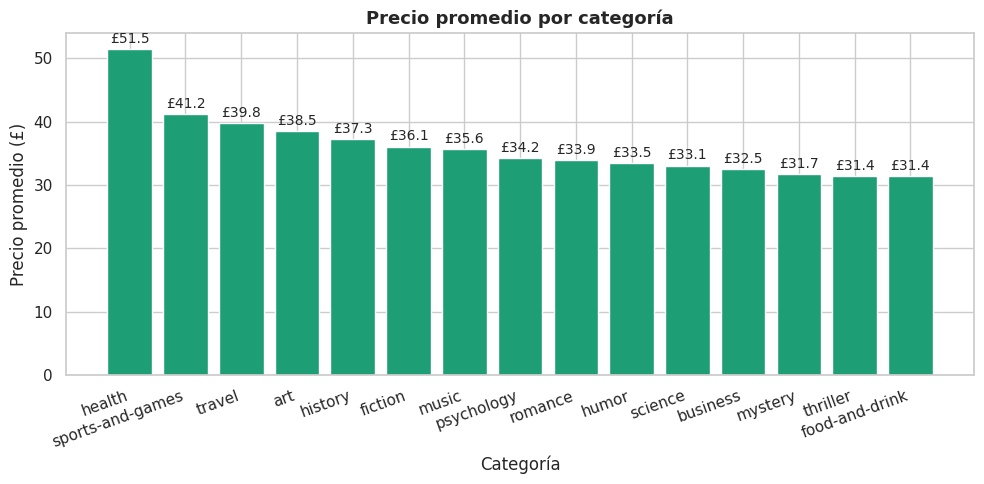

In [23]:
# Gráfica 2: Precio promedio por categoría
precio_categoria = df.groupby("categoria")["precio"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(precio_categoria.index, precio_categoria.values, color="#1D9E75", edgecolor="white")
plt.title("Precio promedio por categoría", fontsize=13, fontweight="bold")
plt.xlabel("Categoría")
plt.ylabel("Precio promedio (£)")
plt.xticks(rotation=20, ha="right")

# Etiqueta encima de cada barra
for bar, val in zip(bars, precio_categoria.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"£{val:.1f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

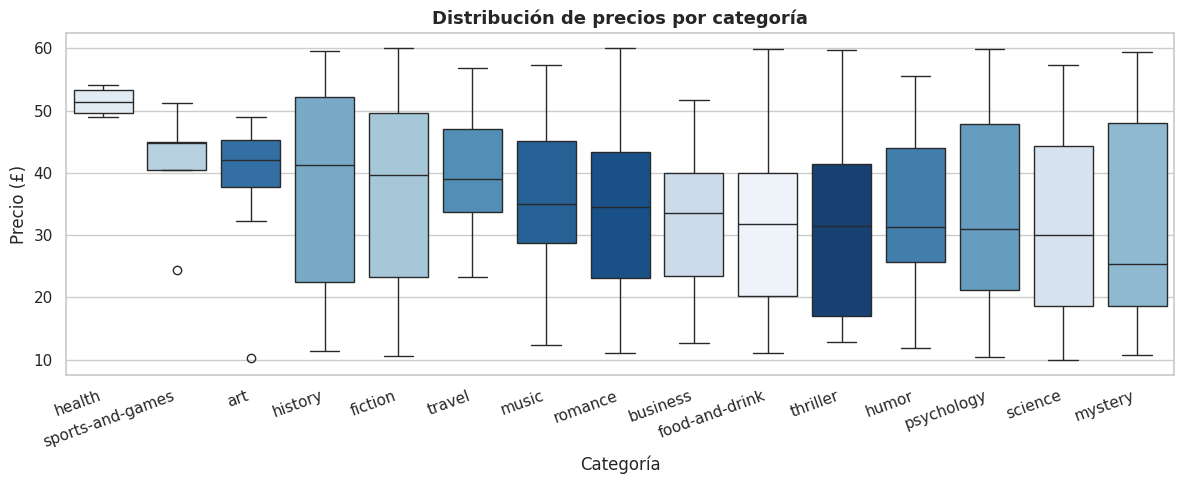

In [28]:
# Gráfica 3: Boxplot de precio por categoría
plt.figure(figsize=(12, 5))
categorias_orden = df.groupby("categoria")["precio"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="categoria", y="precio", order=categorias_orden,
            hue="categoria", palette="Blues", legend=False)
plt.title("Distribución de precios por categoría", fontsize=13, fontweight="bold")
plt.xlabel("Categoría")
plt.ylabel("Precio (£)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

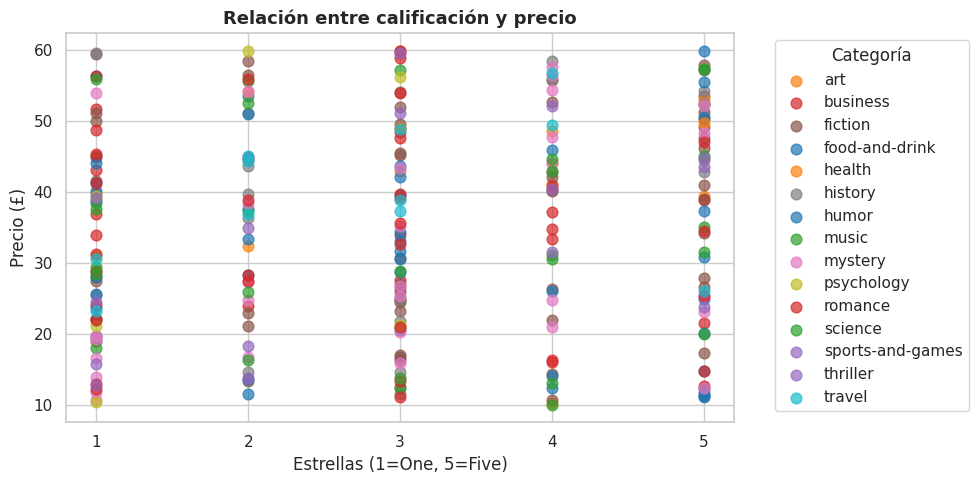

In [26]:
# Gráfica 4: Relación entre precio y calificación (scatter)
plt.figure(figsize=(10, 5))

# Colores automáticos para cualquier cantidad de categorías
palette = sns.color_palette("tab10", n_colors=df["categoria"].nunique())
colores_auto = dict(zip(df["categoria"].unique(), palette))

for cat, grupo in df.groupby("categoria"):
    plt.scatter(grupo["estrellas_num"], grupo["precio"],
                label=cat, color=colores_auto[cat], alpha=0.7, s=60)

plt.title("Relación entre calificación y precio", fontsize=13, fontweight="bold")
plt.xlabel("Estrellas (1=One, 5=Five)")
plt.ylabel("Precio (£)")
plt.xticks([1, 2, 3, 4, 5])
plt.legend(title="Categoría", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

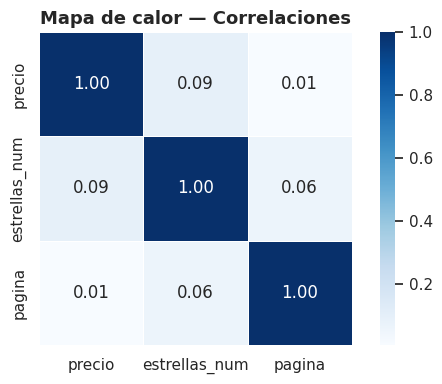


📊 Interpretación:
Correlación precio-estrellas: 0.09
→ Cercana a 0 indica que el precio NO depende de la calificación


In [27]:
# Gráfica 5: Heatmap de correlaciones entre variables numéricas
plt.figure(figsize=(6, 4))
correlaciones = df[["precio", "estrellas_num", "pagina"]].corr()
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="Blues",
            linewidths=0.5, square=True)
plt.title("Mapa de calor — Correlaciones", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n📊 Interpretación:")
print(f"Correlación precio-estrellas: {correlaciones.loc['precio','estrellas_num']:.2f}")
print("→ Cercana a 0 indica que el precio NO depende de la calificación")

## Fase IV — Machine Learning y Optimización

In [29]:
le = LabelEncoder()
df["categoria_encoded"] = le.fit_transform(df["categoria"])

X = df[["estrellas_num", "categoria_encoded", "pagina"]]
y = df["precio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Entrenamiento: {X_train.shape} | Prueba: {X_test.shape}")
print("✅ Datos listos")

Entrenamiento: (220, 3) | Prueba: (55, 3)
✅ Datos listos


In [30]:
from sklearn.ensemble import RandomForestRegressor

modelo_base = RandomForestRegressor(random_state=42)
modelo_base.fit(X_train, y_train)  # Random Forest no necesita escalado

y_pred_base = modelo_base.predict(X_test)
score_base  = modelo_base.score(X_test, y_test)
rmse_base   = np.sqrt(mean_squared_error(y_test, y_pred_base))

print("=== MODELO BASE Random Forest (sin optimizar) ===")
print(f"R² Score : {score_base:.4f}")
print(f"RMSE     : £{rmse_base:.2f}")

=== MODELO BASE Random Forest (sin optimizar) ===
R² Score : -0.3727
RMSE     : £18.24


In [31]:
parametros = {
    "n_estimators"     : [50, 100, 200],
    "max_depth"        : [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator  = RandomForestRegressor(random_state=42),
    param_grid = parametros,
    cv         = 5,
    scoring    = "r2",
    verbose    = 1,
    n_jobs     = -1
)

grid_search.fit(X_train, y_train)

print("\n✅ GridSearchCV completado")
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor R² en CV:     {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits

✅ GridSearchCV completado
Mejores parámetros: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
Mejor R² en CV:     -0.0482


In [32]:
mejor_modelo  = grid_search.best_estimator_
y_pred_opt    = mejor_modelo.predict(X_test)
score_opt     = mejor_modelo.score(X_test, y_test)
rmse_opt      = np.sqrt(mean_squared_error(y_test, y_pred_opt))

print("=== MODELO OPTIMIZADO ===")
print(f"R² Score : {score_opt:.4f}")
print(f"RMSE     : £{rmse_opt:.2f}")

=== MODELO OPTIMIZADO ===
R² Score : -0.1676
RMSE     : £16.82


╔══════════════════════════════════════════╗
║     COMPARACIÓN: BASE vs OPTIMIZADO      ║
╠══════════════════════════════════════════╣
║ R² Base        : -0.3727                  ║
║ R² Optimizado  : -0.1676                  ║
║ Mejora R²      : +0.2051                 ║
║ RMSE Base      : £18.24                 ║
║ RMSE Optimizado: £16.82                 ║
╚══════════════════════════════════════════╝


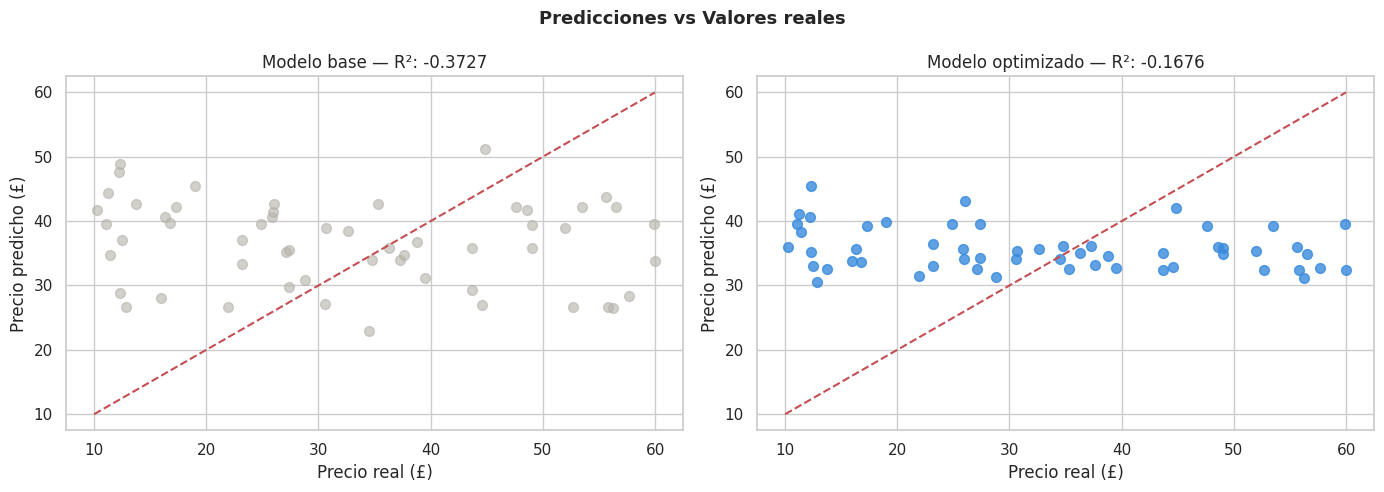

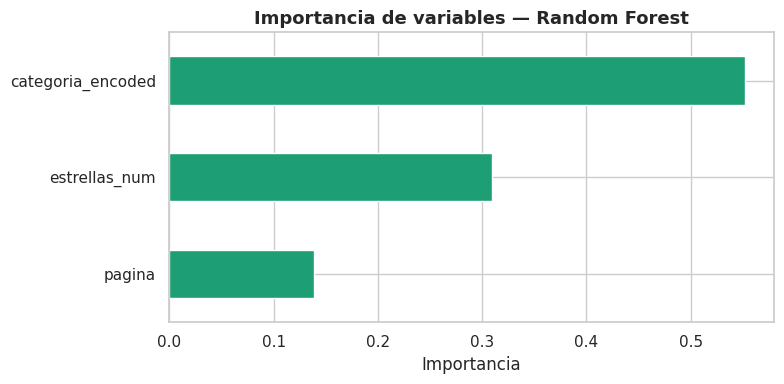


📊 Cross-validation final (5 folds):
   Scores: [np.float64(-0.1665), np.float64(-0.1463), np.float64(-0.0685), np.float64(-0.0741), np.float64(-0.0845)]
   Promedio R²: -0.1080 ± 0.0404


In [33]:
print("╔══════════════════════════════════════════╗")
print("║     COMPARACIÓN: BASE vs OPTIMIZADO      ║")
print("╠══════════════════════════════════════════╣")
print(f"║ R² Base        : {score_base:.4f}                  ║")
print(f"║ R² Optimizado  : {score_opt:.4f}                  ║")
print(f"║ Mejora R²      : +{(score_opt - score_base):.4f}                 ║")
print(f"║ RMSE Base      : £{rmse_base:.2f}                 ║")
print(f"║ RMSE Optimizado: £{rmse_opt:.2f}                 ║")
print("╚══════════════════════════════════════════╝")

# Gráfica 1: Predicciones vs reales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_base, alpha=0.6, color="#B4B2A9", s=50)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=1.5)
axes[0].set_title(f"Modelo base — R²: {score_base:.4f}")
axes[0].set_xlabel("Precio real (£)")
axes[0].set_ylabel("Precio predicho (£)")

axes[1].scatter(y_test, y_pred_opt, alpha=0.8, color="#378ADD", s=50)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=1.5)
axes[1].set_title(f"Modelo optimizado — R²: {score_opt:.4f}")
axes[1].set_xlabel("Precio real (£)")
axes[1].set_ylabel("Precio predicho (£)")

plt.suptitle("Predicciones vs Valores reales", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Gráfica 2: Importancia de variables
importancias = pd.Series(mejor_modelo.feature_importances_,
                         index=["estrellas_num", "categoria_encoded", "pagina"])
importancias.sort_values().plot(kind="barh", color="#1D9E75", figsize=(8, 4))
plt.title("Importancia de variables — Random Forest", fontsize=13, fontweight="bold")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

# Validación cruzada final
cv_scores = cross_val_score(mejor_modelo, X, y, cv=5, scoring="r2")
print(f"\n📊 Cross-validation final (5 folds):")
print(f"   Scores: {[round(s, 4) for s in cv_scores]}")
print(f"   Promedio R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")